# Task 2: Data Analytics Assessment

## Step 1: Column-Wise Analysis

In [444]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

## Load File

In [445]:
data = pd.read_excel('DA -Task 2..xlsx')
data.head()

,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NM,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VPPC,...,TRANSMISSION_TRACE_NBR,SRC_TXN_ID,SRC_VER_NBR,TRANSACTION_CNTR,MEDIA_FLAG,VIN_MODL_DESGTR,LINE_SERIES,LAST_KNOWN_DELVRY_TYPE_CD,NON_CAUSAL_PART_QTY,SALES_REGION_CODE
0,3HCFDDE89SH220903,13021,REPLACED STEERING WHEEL NOW OKAY,STEERING WHEEL COMING APART,2024-01-02,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCF,...,S2210121CNJX0941,2808908219,6,1,N,CF10543,1500,21.0,0,1
1,1HRFFEE8XSZ230636,13028,CHECKED - FOUND DTC'S U0229 - U1530 SET IN BCM...,CUSTOMER STATES HEATED STEERING WHEEL INOP,2024-01-03,MODULE ASM-STRG WHL HT CONT,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1CGF,...,R2210881CNJX0287,2808841910,6,1,Y,TF10543,1500,10.0,0,1
2,1HYKSMRK6SZ000990,13035,APPROVED 4.9(OLH) FOR ADDED DIAGNOSTICS WITH T...,OWNER REPORTS: THE SUPER CRUISE BAR ON THE STE...,2024-01-04,WHEEL ASM-STRG *BACKEN BLACKK,Steering Wheel Replacement,BEV,4 Door Utility,L233-LSOP,...,NaN,2809979441,4,1,Y,6MB26,Lux-1,10.0,0,1
3,3HCFDFEL3SH241701,13021,STEERING WHEEL REPLACEMENT,CUSTOMER STATES THE LETTERING AND FINISH ON TH...,2024-01-04,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCF,...,S1210822CKJX0291,2808892288,6,1,Y,CF10543,1500,10.0,0,1
4,1HRFFHEL1RZ181474,13021,REPLACED STEERING MESSAGE NO LONGER DISPLAYED,C/S: CUSTOMER STATES THE SERVICE DRIVER ASSIST...,2024-01-05,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CGF,...,R2212982CKJX0282,2808901882,8,1,N,TF10543,1500,10.0,0,1


## Column-Wise Analysis

In [446]:
column_analysis = pd.DataFrame({
    "Data Type": data.dtypes,
    "Unique Values": data.nunique(),
    "Missing Values": data.isnull().sum(),
    "Example Value": data.iloc[0]
})

column_analysis.sort_values("Missing Values", ascending=False).head(10) 

,Data Type,Unique Values,Missing Values,Example Value
CAMPAIGN_NBR,float64,0,100,NaN
ENGINE_TRACE_NBR,object,88,12,V2210281MFTX0488
TRANSMISSION_TRACE_NBR,object,88,12,S2210121CNJX0941
ENGINE_SOURCE_PLANT,object,9,12,70628511
TRANSMISSION_SOURCE_PLANT,float64,6,12,287827.0
OPTN_FAMLY_CERTIFICATION,object,3,10,FE9
TOTALCOST,float64,94,6,370.03
OPTF_FAMLY_EMISSIOF_SYSTEM,object,8,5,FTB
CAUSAL_PART_NM,object,18,5,WHEEL ASM-STRG *JET BLACK
LAST_KNOWN_DELVRY_TYPE_CD,float64,11,2,21.0


### Data Cleaning

In [447]:
data_copy = data.copy()
# Since CAMPAIGN_NBR column is completely null we will drop it.
data_copy.drop(columns=['CAMPAIGN_NBR'], inplace=True)
data_copy.head()


data_copy.iloc[:5,:40]



,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NM,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VPPC,...,TRANSACTION_CATEGORY,REPORTING_COST,TOTALCOST,LBRCOST,ENGINE,ENGINE_DESC,TRANSMISSION,TRANSMISSION_DESC,ENGINE_SOURCE_PLANT,ENGINE_TRACE_NBR
0,3HCFDDE89SH220903,13021,REPLACED STEERING WHEEL NOW OKAY,STEERING WHEEL COMING APART,2024-01-02,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCF,...,FREG,370.03,370.03,61.46,LZ0,"DIESEL, 6 CYL, 3.0L, CRI, L6, DOHC, TURBO, VGT...",MQC,"BYT 10 SPD, 10L80, ATSS, ETRS, CPA, GEN 2",70628511,V2210281MFTX0488
1,1HRFFEE8XSZ230636,13028,CHECKED - FOUND DTC'S U0229 - U1530 SET IN BCM...,CUSTOMER STATES HEATED STEERING WHEEL INOP,2024-01-03,MODULE ASM-STRG WHL HT CONT,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1CGF,...,FREG,307.32,307.32,291.14,LZ0,"DIESEL, 6 CYL, 3.0L, CRI, L6, DOHC, TURBO, VGT...",MQC,"BYT 10 SPD, 10L80, ATSS, ETRS, CPA, GEN 2",70628511,V2210291MFTX0188
2,1HYKSMRK6SZ000990,13035,APPROVED 4.9(OLH) FOR ADDED DIAGNOSTICS WITH T...,OWNER REPORTS: THE SUPER CRUISE BAR ON THE STE...,2024-01-04,WHEEL ASM-STRG *BACKEN BLACKK,Steering Wheel Replacement,BEV,4 Door Utility,L233-LSOP,...,FREG,2457.45,3205.45,1012.67,EN0,NONE,MF1,NONE,NaN,NaN
3,3HCFDFEL3SH241701,13021,STEERING WHEEL REPLACEMENT,CUSTOMER STATES THE LETTERING AND FINISH ON TH...,2024-01-04,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCF,...,FREG,445.28,445.28,63.18,L87,"GAS, 8 CYL, V8, 6.2L, DI, DFM, ALUM, GEN 5",MHS,"BYT 10 SPD, 10L80, GRX, GEN 1, ATSS, ETRS, VAR 1",830107152,N2210821MFYX0482
4,1HRFFHEL1RZ181474,13021,REPLACED STEERING MESSAGE NO LONGER DISPLAYED,C/S: CUSTOMER STATES THE SERVICE DRIVER ASSIST...,2024-01-05,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CGF,...,FREG,1439.65,1439.65,136.00,L87,"GAS, 8 CYL, V8, 6.2L, DI, DFM, ALUM, GEN 5",MHS,"BYT 10 SPD, 10L80, GRX, GEN 1, ATSS, ETRS, VAR 1",830107152,N2212994MGPX0790


In [448]:
from sklearn.impute import SimpleImputer

# Define columns to impute
most_freq_cols = [
    'CAUSAL_PART_NM', 'PLANT', 'STATE', 'REPAIR_DLR_POSTAL_CD', 'VEH_TEST_GRP',
    'OPTN_FAMLY_CERTIFICATION', 'OPTF_FAMLY_EMISSIOF_SYSTEM', 'ENGINE_SOURCE_PLANT',
    'ENGINE_TRACE_NBR', 'TRANSMISSION_TRACE_NBR', 'LINE_SERIES'
]

# Replace blank strings or "nan"/"NA" text with np.nan
data_copy[most_freq_cols] = data_copy[most_freq_cols].replace(['', ' ', 'NA', 'NaN', 'nan'], np.nan)

# Cast to string to ensure no mixed types
data_copy[most_freq_cols] = data_copy[most_freq_cols].astype(str)
data_copy[most_freq_cols] = data_copy[most_freq_cols].replace('nan', np.nan)  # Replace actual 'nan' string again

# Impute with most frequent value
most_freq_imputer = SimpleImputer(strategy='most_frequent')
data_copy[most_freq_cols] = most_freq_imputer.fit_transform(data_copy[most_freq_cols])

# Confirm if any NaNs left
print("NaNs after imputation:\n", data_copy[most_freq_cols].isnull().sum())


data_copy.head(100)

NaNs after imputation:
 CAUSAL_PART_NM                0
PLANT                         0
STATE                         0
REPAIR_DLR_POSTAL_CD          0
VEH_TEST_GRP                  0
OPTN_FAMLY_CERTIFICATION      0
OPTF_FAMLY_EMISSIOF_SYSTEM    0
ENGINE_SOURCE_PLANT           0
ENGINE_TRACE_NBR              0
TRANSMISSION_TRACE_NBR        0
LINE_SERIES                   0
dtype: int64


,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NM,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VPPC,...,TRANSMISSION_TRACE_NBR,SRC_TXN_ID,SRC_VER_NBR,TRANSACTION_CNTR,MEDIA_FLAG,VIN_MODL_DESGTR,LINE_SERIES,LAST_KNOWN_DELVRY_TYPE_CD,NON_CAUSAL_PART_QTY,SALES_REGION_CODE
0,3HCFDDE89SH220903,13021,REPLACED STEERING WHEEL NOW OKAY,STEERING WHEEL COMING APART,2024-01-02,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCF,...,S2210121CNJX0941,2808908219,6,1,N,CF10543,1500,21.0,0,1
1,1HRFFEE8XSZ230636,13028,CHECKED - FOUND DTC'S U0229 - U1530 SET IN BCM...,CUSTOMER STATES HEATED STEERING WHEEL INOP,2024-01-03,MODULE ASM-STRG WHL HT CONT,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1CGF,...,R2210881CNJX0287,2808841910,6,1,Y,TF10543,1500,10.0,0,1
2,1HYKSMRK6SZ000990,13035,APPROVED 4.9(OLH) FOR ADDED DIAGNOSTICS WITH T...,OWNER REPORTS: THE SUPER CRUISE BAR ON THE STE...,2024-01-04,WHEEL ASM-STRG *BACKEN BLACKK,Steering Wheel Replacement,BEV,4 Door Utility,L233-LSOP,...,21210129IKBP0429,2809979441,4,1,Y,6MB26,Lux-1,10.0,0,1
3,3HCFDFEL3SH241701,13021,STEERING WHEEL REPLACEMENT,CUSTOMER STATES THE LETTERING AND FINISH ON TH...,2024-01-04,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCF,...,S1210822CKJX0291,2808892288,6,1,Y,CF10543,1500,10.0,0,1
4,1HRFFHEL1RZ181474,13021,REPLACED STEERING MESSAGE NO LONGER DISPLAYED,C/S: CUSTOMER STATES THE SERVICE DRIVER ASSIST...,2024-01-05,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CGF,...,R2212982CKJX0282,2808901882,8,1,N,TF10543,1500,10.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1HYKNHRS6MZ221833,13041,REPLACED STEERING WHEEL COMPLETEDLOP 0130 TIME .4,CUSTOMER STATES that the steering is very tigh...,2024-02-07,WHEEL ASM-STRG *BLACK,Steering Wheel Replacement,Global Crossover Vehicles,4 Door Utility,C1UL,...,22222280KKBP0890,2820784987,4,1,Y,6NJ26,Sport,15.0,1,1
96,1HYKSSRL4SZ003381,13048,replace steering wheel,cs driver assistance warning light is coming o...,2024-02-07,WHEEL ASM-STRG *BACKEN BLACKK,Steering Wheel Replacement,BEV,4 Door Utility,L233-LSOP,...,21210129IKBP0429,2822282187,6,1,N,6MB26,1500,10.0,0,1
97,1HKKNXLS3SZ128369,13044,REPLACE STEERING WHEEL PRA 496735300000,CUSTOMER STATESCUSTOMER STATES VEHICLE STEERIN...,2024-02-07,WHEEL ASM-STRG *BLACK,Steering Wheel Replacement,Crossover SUV,4 Door Utility,C1UG,...,21222222SKBP0119,2822042248,4,1,N,TNN26,Denali,10.0,0,1
98,1HC4WLE78RF260518,13045,REMOVED STEERING WHEEL AND DISASSEMBLED AND FO...,CUSTOMER STATES THERE IS CLICKING TYPE NOISE C...,2024-02-07,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCH,...,Y0212811MRFX0180,2820879999,6,1,N,CC20943,2500,14.0,0,1


In [449]:
from sklearn.impute import SimpleImputer


# Define columns
median_cols = ['TOTALCOST', 'TRANSMISSION_SOURCE_PLANT', 'LAST_KNOWN_DELVRY_TYPE_CD']

# Replace non-numeric junk with np.nan
for col in median_cols:
    data_copy[col] = pd.to_numeric(data_copy[col], errors='coerce')

# Now apply median imputer
median_imputer = SimpleImputer(strategy='median')
data_copy[median_cols] = median_imputer.fit_transform(data_copy[median_cols])

# Check again
print(data_copy[median_cols].isnull().sum())

data_copy.head(100)



TOTALCOST                    0
TRANSMISSION_SOURCE_PLANT    0
LAST_KNOWN_DELVRY_TYPE_CD    0
dtype: int64


,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NM,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VPPC,...,TRANSMISSION_TRACE_NBR,SRC_TXN_ID,SRC_VER_NBR,TRANSACTION_CNTR,MEDIA_FLAG,VIN_MODL_DESGTR,LINE_SERIES,LAST_KNOWN_DELVRY_TYPE_CD,NON_CAUSAL_PART_QTY,SALES_REGION_CODE
0,3HCFDDE89SH220903,13021,REPLACED STEERING WHEEL NOW OKAY,STEERING WHEEL COMING APART,2024-01-02,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCF,...,S2210121CNJX0941,2808908219,6,1,N,CF10543,1500,21.0,0,1
1,1HRFFEE8XSZ230636,13028,CHECKED - FOUND DTC'S U0229 - U1530 SET IN BCM...,CUSTOMER STATES HEATED STEERING WHEEL INOP,2024-01-03,MODULE ASM-STRG WHL HT CONT,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1CGF,...,R2210881CNJX0287,2808841910,6,1,Y,TF10543,1500,10.0,0,1
2,1HYKSMRK6SZ000990,13035,APPROVED 4.9(OLH) FOR ADDED DIAGNOSTICS WITH T...,OWNER REPORTS: THE SUPER CRUISE BAR ON THE STE...,2024-01-04,WHEEL ASM-STRG *BACKEN BLACKK,Steering Wheel Replacement,BEV,4 Door Utility,L233-LSOP,...,21210129IKBP0429,2809979441,4,1,Y,6MB26,Lux-1,10.0,0,1
3,3HCFDFEL3SH241701,13021,STEERING WHEEL REPLACEMENT,CUSTOMER STATES THE LETTERING AND FINISH ON TH...,2024-01-04,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCF,...,S1210822CKJX0291,2808892288,6,1,Y,CF10543,1500,10.0,0,1
4,1HRFFHEL1RZ181474,13021,REPLACED STEERING MESSAGE NO LONGER DISPLAYED,C/S: CUSTOMER STATES THE SERVICE DRIVER ASSIST...,2024-01-05,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CGF,...,R2212982CKJX0282,2808901882,8,1,N,TF10543,1500,10.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1HYKNHRS6MZ221833,13041,REPLACED STEERING WHEEL COMPLETEDLOP 0130 TIME .4,CUSTOMER STATES that the steering is very tigh...,2024-02-07,WHEEL ASM-STRG *BLACK,Steering Wheel Replacement,Global Crossover Vehicles,4 Door Utility,C1UL,...,22222280KKBP0890,2820784987,4,1,Y,6NJ26,Sport,15.0,1,1
96,1HYKSSRL4SZ003381,13048,replace steering wheel,cs driver assistance warning light is coming o...,2024-02-07,WHEEL ASM-STRG *BACKEN BLACKK,Steering Wheel Replacement,BEV,4 Door Utility,L233-LSOP,...,21210129IKBP0429,2822282187,6,1,N,6MB26,1500,10.0,0,1
97,1HKKNXLS3SZ128369,13044,REPLACE STEERING WHEEL PRA 496735300000,CUSTOMER STATESCUSTOMER STATES VEHICLE STEERIN...,2024-02-07,WHEEL ASM-STRG *BLACK,Steering Wheel Replacement,Crossover SUV,4 Door Utility,C1UG,...,21222222SKBP0119,2822042248,4,1,N,TNN26,Denali,10.0,0,1
98,1HC4WLE78RF260518,13045,REMOVED STEERING WHEEL AND DISASSEMBLED AND FO...,CUSTOMER STATES THERE IS CLICKING TYPE NOISE C...,2024-02-07,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCH,...,Y0212811MRFX0180,2820879999,6,1,N,CC20943,2500,14.0,0,1


In [450]:
# Original and corrected text
original_snippet = "方向盘底部的皮革脱落"
corrected_text = "Removed the damaged steering wheel due to leather detachment at the bottom and installed a new steering wheel assembly. CC: 0890 FC: 2039 PRA#: 490428700000 Labor OP: 0130 0.50 hours"

# Function to replace matching text
def correct_text(val):
    if isinstance(val, str) and re.search(original_snippet, val):
        return corrected_text
    return val

# Apply correction
data_copy['CORRECTION_VERBATIM'] = data_copy['CORRECTION_VERBATIM'].apply(correct_text)

# Show replaced rows (for verification)
#print(data_copy[data_copy['CORRECTION_VERBATIM'].str.contains("steering wheel", na=False)][['CORRECTION_VERBATIM']])


data_copy.head(76)


,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NM,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VPPC,...,TRANSMISSION_TRACE_NBR,SRC_TXN_ID,SRC_VER_NBR,TRANSACTION_CNTR,MEDIA_FLAG,VIN_MODL_DESGTR,LINE_SERIES,LAST_KNOWN_DELVRY_TYPE_CD,NON_CAUSAL_PART_QTY,SALES_REGION_CODE
0,3HCFDDE89SH220903,13021,REPLACED STEERING WHEEL NOW OKAY,STEERING WHEEL COMING APART,2024-01-02,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCF,...,S2210121CNJX0941,2808908219,6,1,N,CF10543,1500,21.0,0,1
1,1HRFFEE8XSZ230636,13028,CHECKED - FOUND DTC'S U0229 - U1530 SET IN BCM...,CUSTOMER STATES HEATED STEERING WHEEL INOP,2024-01-03,MODULE ASM-STRG WHL HT CONT,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1CGF,...,R2210881CNJX0287,2808841910,6,1,Y,TF10543,1500,10.0,0,1
2,1HYKSMRK6SZ000990,13035,APPROVED 4.9(OLH) FOR ADDED DIAGNOSTICS WITH T...,OWNER REPORTS: THE SUPER CRUISE BAR ON THE STE...,2024-01-04,WHEEL ASM-STRG *BACKEN BLACKK,Steering Wheel Replacement,BEV,4 Door Utility,L233-LSOP,...,21210129IKBP0429,2809979441,4,1,Y,6MB26,Lux-1,10.0,0,1
3,3HCFDFEL3SH241701,13021,STEERING WHEEL REPLACEMENT,CUSTOMER STATES THE LETTERING AND FINISH ON TH...,2024-01-04,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCF,...,S1210822CKJX0291,2808892288,6,1,Y,CF10543,1500,10.0,0,1
4,1HRFFHEL1RZ181474,13021,REPLACED STEERING MESSAGE NO LONGER DISPLAYED,C/S: CUSTOMER STATES THE SERVICE DRIVER ASSIST...,2024-01-05,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CGF,...,R2212982CKJX0282,2808901882,8,1,N,TF10543,1500,10.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,1HKS2CKL2NR279082,13036,CHECKED AND FOUND CODE -B1A4C-92-HEATED STEERI...,CUSTOMER STATES THAT THE HEATED STEERING WHEEL...,2024-01-31,"WHEEL ASM,STRG",Steering Wheel Replacement,Full-Size Utility,4 Door Utility,T1UGF,...,S2220782CKJX0921,2820194999,4,1,N,TF10706,1500,10.0,0,1
72,3HRFFCER0NH647253,13037,replaced steering wheel and retest system oper...,CUST STATES STEERING WHEEL DOES NOT HEAT UP CO...,2024-01-31,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CGF,...,S1222081CNJX2982,2820198294,6,1,N,TF10543,1500,10.0,0,1
73,3HCFDHEL2SH305075,13038,Removed the damaged steering wheel due to leat...,LEATHER ON STEERING WHEEL COMING LOOSE ON BOTTOM.,2024-01-31,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCF,...,S2212292CKJX0982,2820191222,4,1,N,CF10543,1500,18.0,0,1
74,1H1FY6S0XN4126832,13060,Replaced steering wheel,Customer states the heated steering wheel does...,2024-02-01,MODULE ASM-STRG WHL HT CONT,Heated Steering Wheel Module Replacement,Global Gamma,4 Door Sedan,C121,...,21210129IKBP0429,2822121929,4,1,N,1FF48,LT,10.0,0,1


In [451]:
import pandas as pd
import re

# List of phrases to remove, including variations and colons
unnecessary_phrases = [
    'Customer States', 'C/S', 'Owner Reports', '#Update#', 'Cust Sts', 'Cust States', 'Cs', 'C.S', 'Ck', 
    'Customer Reported', 'Customer Complaint', 'Customer Request', 'Customer Says', 'Customer Mentioned',
    'C/C', 'CUST. STATES', 'C/S', 'GUEST STATES', 'CUSTOMER STATE', 'GUEST STATE'
]

# Create a regex pattern to match all unnecessary phrases (case insensitive), also removing colons, and spaces
pattern = r'\b(' + '|'.join(map(re.escape, unnecessary_phrases)) + r')\s*:*\s*|#UPDATE#|:'

# Function to clean the 'CUSTOMER_VERBATIM' column in-place
def clean_verbatim(text):
    text = re.sub(pattern, '', text, flags=re.IGNORECASE).strip()  # Remove the phrases and colons, and strip spaces
    return text

# Apply the cleaning function directly to the 'CUSTOMER_VERBATIM' column in the same dataset
data_copy['CUSTOMER_VERBATIM'] = data_copy['CUSTOMER_VERBATIM'].apply(lambda x: clean_verbatim(str(x)))


data_copy.tail(50)



,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NM,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VPPC,...,TRANSMISSION_TRACE_NBR,SRC_TXN_ID,SRC_VER_NBR,TRANSACTION_CNTR,MEDIA_FLAG,VIN_MODL_DESGTR,LINE_SERIES,LAST_KNOWN_DELVRY_TYPE_CD,NON_CAUSAL_PART_QTY,SALES_REGION_CODE
50,1H1JD5SB0L4142407,13039,replace steering wheel sop ordered on ro 412613,THE STEERING WHEEL IS PEALING AND SEPARATING-I...,2024-01-25,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Global Gamma Vehicles,4 Door Sedan,G1SC,...,928ZGWK0222A0928,2820019979,8,1,Y,1JV69,LT(Automatic),10.0,0,1
51,1HYKN9RS3NZ156257,13034,STEERING WHEEL COVER REPLACEMENT PART IN BACKO...,STEERING WHEEL MOLDING CAME OFF,2024-01-25,COVER-STRG WHL SPOKE *HI GLOSS V-C,Steering Wheel Spoke Cover Replacement,Global Crossover Vehicles,4 Door Utility,C1UL,...,22220842SKBP2444,2820029101,4,1,Y,6NJ26,Export Only,10.0,0,1
52,1HRS9EED9MZ268771,13037,REPLACED STEERING WHEEL ASSEMBLY. CUSTOMER TO ...,THE STEERING WHEEL IS PEELING IN SOME AREAS. A...,2024-01-25,WHEEL ASM-STRG *BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CGF,...,R2220912BKJX0288,2809914920,8,1,Y,TF10543,1500,10.0,0,1
53,1HKS2JKL7SR422793,13033,Replaced steering wheel,"THE STITCHING ON STEERING WHEEL IS LOOSE, PLEA...",2024-01-26,WHEEL ASM-STRG *FAWN,Steering Wheel Replacement,Full-Size Utility,4 Door Utility,T1YGF,...,S2212922CKJX2091,2820007922,4,1,N,TF10906,1500,21.0,0,1
54,1HYKNHRS5NZ163005,13034,REPLACED COVER,BEZEL ON STEERING WHEEL IS COMING APART. PART ...,2024-01-26,COVER-STRG WHL SPOKE *HI GLOSS V-C,Steering Wheel Spoke Cover Replacement,Global Crossover Vehicles,4 Door Utility,C1UL,...,22220922SKBP2889,2820229149,2,1,N,6NJ26,Sport,15.0,0,1
55,3HCFYHED7NH206711,13034,REPLACED STEERING WHEEL AND RETESTED OPERATION...,"THAT THE CRUISE CONTROL IS NOT WORKING, THAT T...",2024-01-26,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1CCF,...,S2220212XNL20712,2820202794,4,1,N,CF18543,1500,10.0,0,1
56,1H1FW6S02N4102661,13054,REPLACE HEATED STEERING MODULE,HEATED VOLAN DEVARQUE BY ITSELF INTERMITTENT C...,2024-01-26,MODULE ASM-STRG WHL HT CONT,Heated Steering Wheel Module Replacement,Global Gamma,4 Door Sedan,C110,...,21210129IKBP0429,2822027490,2,1,N,1FB48,1LT,10.0,0,1
57,1HYFZFR46SF102560,13034,"installed steering wheel from last visit, test...",VEHICLE'S STEERING WHEEL WAS SMOKING OUT OF TH...,2024-01-26,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,GLOBAL EPSILON II,4 Door Utility,E2UL,...,22222412IRBP0492,2820282072,6,1,Y,6ZE26,Sport,10.0,0,1
58,1H1FZ6S01N4111553,13043,DIAGNOSE HEATED STEERING WHEEL DOES NOT GET WA...,HEATED STEERING WHEEL IS NOT WORKING,2024-01-26,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Global Gamma,4 Door Sedan,C121,...,21210129IKBP0429,2820027898,6,1,Y,1FG48,Premier,10.0,0,1
59,1H1FZ6S08N4104213,13081,C-S SUPER CRUISE INOP. VERIFIED SUPER CRUISE I...,SUPERCRUISE DOES NOT WORK. DIAGNOSE AND ADVISE.,2024-01-27,WHEEL ASM-STRG *JET BLACK,Steering Wheel Replacement,Global Gamma,4 Door Sedan,C121,...,21210129IKBP0429,2822884894,6,1,Y,1FG48,Premier,10.0,1,1


## Inconsistencies in Categorical Columns - Capitalization,  Inconsistent,  Typos

## Capitalization

In [452]:
#data_copy = data.copy()
for col in data_copy.select_dtypes(include='object').columns:
    data_copy[col] = data_copy[col].astype(str).str.strip().str.title()
data_copy.head(100)

,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NM,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VPPC,...,TRANSMISSION_TRACE_NBR,SRC_TXN_ID,SRC_VER_NBR,TRANSACTION_CNTR,MEDIA_FLAG,VIN_MODL_DESGTR,LINE_SERIES,LAST_KNOWN_DELVRY_TYPE_CD,NON_CAUSAL_PART_QTY,SALES_REGION_CODE
0,3Hcfdde89Sh220903,13021,Replaced Steering Wheel Now Okay,Steering Wheel Coming Apart,2024-01-02,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,S2210121Cnjx0941,2808908219,6,1,N,Cf10543,1500,21.0,0,1
1,1Hrffee8Xsz230636,13028,Checked - Found Dtc'S U0229 - U1530 Set In Bcm...,Heated Steering Wheel Inop,2024-01-03,Module Asm-Strg Whl Ht Cont,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,R2210881Cnjx0287,2808841910,6,1,Y,Tf10543,1500,10.0,0,1
2,1Hyksmrk6Sz000990,13035,Approved 4.9(Olh) For Added Diagnostics With T...,The Super Cruise Bar On The Steering Wheel Is ...,2024-01-04,Wheel Asm-Strg *Backen Blackk,Steering Wheel Replacement,Bev,4 Door Utility,L233-Lsop,...,21210129Ikbp0429,2809979441,4,1,Y,6Mb26,Lux-1,10.0,0,1
3,3Hcfdfel3Sh241701,13021,Steering Wheel Replacement,The Lettering And Finish On The Steering Wheel...,2024-01-04,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,S1210822Ckjx0291,2808892288,6,1,Y,Cf10543,1500,10.0,0,1
4,1Hrffhel1Rz181474,13021,Replaced Steering Message No Longer Displayed,The Service Driver Assist System Message Is On...,2024-01-05,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,R2212982Ckjx0282,2808901882,8,1,N,Tf10543,1500,10.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1Hyknhrs6Mz221833,13041,Replaced Steering Wheel Completedlop 0130 Time .4,That The Steering Is Very Tight And You Can He...,2024-02-07,Wheel Asm-Strg *Black,Steering Wheel Replacement,Global Crossover Vehicles,4 Door Utility,C1Ul,...,22222280Kkbp0890,2820784987,4,1,Y,6Nj26,Sport,15.0,1,1
96,1Hykssrl4Sz003381,13048,Replace Steering Wheel,Driver Assistance Warning Light Is Coming On W...,2024-02-07,Wheel Asm-Strg *Backen Blackk,Steering Wheel Replacement,Bev,4 Door Utility,L233-Lsop,...,21210129Ikbp0429,2822282187,6,1,N,6Mb26,1500,10.0,0,1
97,1Hkknxls3Sz128369,13044,Replace Steering Wheel Pra 496735300000,Customer States Vehicle Steering Wheel Coming ...,2024-02-07,Wheel Asm-Strg *Black,Steering Wheel Replacement,Crossover Suv,4 Door Utility,C1Ug,...,21222222Skbp0119,2822042248,4,1,N,Tnn26,Denali,10.0,0,1
98,1Hc4Wle78Rf260518,13045,Removed Steering Wheel And Disassembled And Fo...,There Is Clicking Type Noise Coming From Steer...,2024-02-07,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cch,...,Y0212811Mrfx0180,2820879999,6,1,N,Cc20943,2500,14.0,0,1


### Inconsistent Value

In [453]:
# Replace any rows with corrupted text pattern
data_copy['CUSTOMER_VERBATIM'] = data_copy['CUSTOMER_VERBATIM'].replace(
    to_replace=r'[^\x00-\x7F]+', value=np.nan, regex=True
)

data_copy.head(100)


,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NM,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VPPC,...,TRANSMISSION_TRACE_NBR,SRC_TXN_ID,SRC_VER_NBR,TRANSACTION_CNTR,MEDIA_FLAG,VIN_MODL_DESGTR,LINE_SERIES,LAST_KNOWN_DELVRY_TYPE_CD,NON_CAUSAL_PART_QTY,SALES_REGION_CODE
0,3Hcfdde89Sh220903,13021,Replaced Steering Wheel Now Okay,Steering Wheel Coming Apart,2024-01-02,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,S2210121Cnjx0941,2808908219,6,1,N,Cf10543,1500,21.0,0,1
1,1Hrffee8Xsz230636,13028,Checked - Found Dtc'S U0229 - U1530 Set In Bcm...,Heated Steering Wheel Inop,2024-01-03,Module Asm-Strg Whl Ht Cont,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,R2210881Cnjx0287,2808841910,6,1,Y,Tf10543,1500,10.0,0,1
2,1Hyksmrk6Sz000990,13035,Approved 4.9(Olh) For Added Diagnostics With T...,The Super Cruise Bar On The Steering Wheel Is ...,2024-01-04,Wheel Asm-Strg *Backen Blackk,Steering Wheel Replacement,Bev,4 Door Utility,L233-Lsop,...,21210129Ikbp0429,2809979441,4,1,Y,6Mb26,Lux-1,10.0,0,1
3,3Hcfdfel3Sh241701,13021,Steering Wheel Replacement,The Lettering And Finish On The Steering Wheel...,2024-01-04,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,S1210822Ckjx0291,2808892288,6,1,Y,Cf10543,1500,10.0,0,1
4,1Hrffhel1Rz181474,13021,Replaced Steering Message No Longer Displayed,The Service Driver Assist System Message Is On...,2024-01-05,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,R2212982Ckjx0282,2808901882,8,1,N,Tf10543,1500,10.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1Hyknhrs6Mz221833,13041,Replaced Steering Wheel Completedlop 0130 Time .4,That The Steering Is Very Tight And You Can He...,2024-02-07,Wheel Asm-Strg *Black,Steering Wheel Replacement,Global Crossover Vehicles,4 Door Utility,C1Ul,...,22222280Kkbp0890,2820784987,4,1,Y,6Nj26,Sport,15.0,1,1
96,1Hykssrl4Sz003381,13048,Replace Steering Wheel,Driver Assistance Warning Light Is Coming On W...,2024-02-07,Wheel Asm-Strg *Backen Blackk,Steering Wheel Replacement,Bev,4 Door Utility,L233-Lsop,...,21210129Ikbp0429,2822282187,6,1,N,6Mb26,1500,10.0,0,1
97,1Hkknxls3Sz128369,13044,Replace Steering Wheel Pra 496735300000,Customer States Vehicle Steering Wheel Coming ...,2024-02-07,Wheel Asm-Strg *Black,Steering Wheel Replacement,Crossover Suv,4 Door Utility,C1Ug,...,21222222Skbp0119,2822042248,4,1,N,Tnn26,Denali,10.0,0,1
98,1Hc4Wle78Rf260518,13045,Removed Steering Wheel And Disassembled And Fo...,There Is Clicking Type Noise Coming From Steer...,2024-02-07,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cch,...,Y0212811Mrfx0180,2820879999,6,1,N,Cc20943,2500,14.0,0,1


In [454]:
from sklearn.impute import SimpleImputer

# Impute using most frequent valid value
imputer = SimpleImputer(strategy='most_frequent')
data_copy[['CUSTOMER_VERBATIM']] = imputer.fit_transform(data_copy[['CUSTOMER_VERBATIM']])

data_copy.head(100)

,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NM,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VPPC,...,TRANSMISSION_TRACE_NBR,SRC_TXN_ID,SRC_VER_NBR,TRANSACTION_CNTR,MEDIA_FLAG,VIN_MODL_DESGTR,LINE_SERIES,LAST_KNOWN_DELVRY_TYPE_CD,NON_CAUSAL_PART_QTY,SALES_REGION_CODE
0,3Hcfdde89Sh220903,13021,Replaced Steering Wheel Now Okay,Steering Wheel Coming Apart,2024-01-02,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,S2210121Cnjx0941,2808908219,6,1,N,Cf10543,1500,21.0,0,1
1,1Hrffee8Xsz230636,13028,Checked - Found Dtc'S U0229 - U1530 Set In Bcm...,Heated Steering Wheel Inop,2024-01-03,Module Asm-Strg Whl Ht Cont,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,R2210881Cnjx0287,2808841910,6,1,Y,Tf10543,1500,10.0,0,1
2,1Hyksmrk6Sz000990,13035,Approved 4.9(Olh) For Added Diagnostics With T...,The Super Cruise Bar On The Steering Wheel Is ...,2024-01-04,Wheel Asm-Strg *Backen Blackk,Steering Wheel Replacement,Bev,4 Door Utility,L233-Lsop,...,21210129Ikbp0429,2809979441,4,1,Y,6Mb26,Lux-1,10.0,0,1
3,3Hcfdfel3Sh241701,13021,Steering Wheel Replacement,The Lettering And Finish On The Steering Wheel...,2024-01-04,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,S1210822Ckjx0291,2808892288,6,1,Y,Cf10543,1500,10.0,0,1
4,1Hrffhel1Rz181474,13021,Replaced Steering Message No Longer Displayed,The Service Driver Assist System Message Is On...,2024-01-05,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,R2212982Ckjx0282,2808901882,8,1,N,Tf10543,1500,10.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1Hyknhrs6Mz221833,13041,Replaced Steering Wheel Completedlop 0130 Time .4,That The Steering Is Very Tight And You Can He...,2024-02-07,Wheel Asm-Strg *Black,Steering Wheel Replacement,Global Crossover Vehicles,4 Door Utility,C1Ul,...,22222280Kkbp0890,2820784987,4,1,Y,6Nj26,Sport,15.0,1,1
96,1Hykssrl4Sz003381,13048,Replace Steering Wheel,Driver Assistance Warning Light Is Coming On W...,2024-02-07,Wheel Asm-Strg *Backen Blackk,Steering Wheel Replacement,Bev,4 Door Utility,L233-Lsop,...,21210129Ikbp0429,2822282187,6,1,N,6Mb26,1500,10.0,0,1
97,1Hkknxls3Sz128369,13044,Replace Steering Wheel Pra 496735300000,Customer States Vehicle Steering Wheel Coming ...,2024-02-07,Wheel Asm-Strg *Black,Steering Wheel Replacement,Crossover Suv,4 Door Utility,C1Ug,...,21222222Skbp0119,2822042248,4,1,N,Tnn26,Denali,10.0,0,1
98,1Hc4Wle78Rf260518,13045,Removed Steering Wheel And Disassembled And Fo...,There Is Clicking Type Noise Coming From Steer...,2024-02-07,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cch,...,Y0212811Mrfx0180,2820879999,6,1,N,Cc20943,2500,14.0,0,1


### Typos

In [455]:
# Fixing Typos for all column Names
rename_dict = {
    "NON_CAUSAL_PART_QTY": "NON_CAUSAL_PART_QUANTITY",
    "LAST_KNOWN_DELVRY_TYPE_CD": "LAST_KNOWN_DELIVERY_TYPE_CODE",
    "VIN_MODL_DESGTR": "VEHICLE_IDENTIFICATION_NUMBER_MODEL_DESIGNER",
    "TRANSACTION_CNTR": "TRANSACTION_COUNTER",
    "SRC_VER_NBR": "SOURCE_VERSION_NUMBER",
    "SRC_TXN_ID": "SOURCE_TRANSACTION_ID",
    "ENGINE_TRACE_NBR": "ENGINE_TRACE_NUMBER",
    "TRANSMISSION_DESC": "TRANSMISSION_DESCRIPTION",
    "ENGINE_DESC": "ENGINE_DESCRIPTION",
    "OPTF_FAMLY_EMISSIOF_SYSTEM": "OPTION_FAMILY_EMISSION_SYSTEM",
    "ORD_SELLING_SRC_CD": "ORDER_SELLING_SOURCE_CODE",
    "COMPLAINT_CD": "COMPLAINT_CODE",
    "VEH_TEST_GRP": "VEHICLE_TEST_GROUP",
    "COUNTRY_SALE_ISO": "COUNTRY_SALE_ISO",
    "OPTN_FAMLY_CERTIFICATION": "OPTION_FAMILY_CERTIFICATION",
    "TRANSMISSION_TRACE_NBR"  : "TRANSMISSION_TRACE_NUMBER",
    "LBRCOST": "LABOR_COST",
    "COMPLAINT_CD_CSI": "COMPLAINT_CODE_CUSTOMER_SATISFACTION_INDEX",
    "KM": "KILOMETERS",
    "REPAIR_DLR_POSTAL_CD": "REPAIR_DEALER_POSTAL_CODE",
    "REPAIR_DLR_CITY": "REPAIR_DEALER_CITY",
    "LAST_KNOWN_DLR_NAME": "LAST_KNOWN_DEALER_NAME",
    "VPPC": "VEHICLE_PRODUCT_CODE",
    "TOTALCOST" :"TOTAL_COST",
    "CAUSAL_PART_NM": "CAUSAL_PART_NAME"
}

# rename the columns
data_copy.rename(columns=rename_dict, inplace=True)


data_copy.head()
data_copy.iloc[:5,:40]

,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NAME,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VEHICLE_PRODUCT_CODE,...,TRANSACTION_CATEGORY,REPORTING_COST,TOTAL_COST,LABOR_COST,ENGINE,ENGINE_DESCRIPTION,TRANSMISSION,TRANSMISSION_DESCRIPTION,ENGINE_SOURCE_PLANT,ENGINE_TRACE_NUMBER
0,3Hcfdde89Sh220903,13021,Replaced Steering Wheel Now Okay,Steering Wheel Coming Apart,2024-01-02,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,Freg,370.03,370.03,61.46,Lz0,"Diesel, 6 Cyl, 3.0L, Cri, L6, Dohc, Turbo, Vgt...",Mqc,"Byt 10 Spd, 10L80, Atss, Etrs, Cpa, Gen 2",70628511,V2210281Mftx0488
1,1Hrffee8Xsz230636,13028,Checked - Found Dtc'S U0229 - U1530 Set In Bcm...,Heated Steering Wheel Inop,2024-01-03,Module Asm-Strg Whl Ht Cont,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,Freg,307.32,307.32,291.14,Lz0,"Diesel, 6 Cyl, 3.0L, Cri, L6, Dohc, Turbo, Vgt...",Mqc,"Byt 10 Spd, 10L80, Atss, Etrs, Cpa, Gen 2",70628511,V2210291Mftx0188
2,1Hyksmrk6Sz000990,13035,Approved 4.9(Olh) For Added Diagnostics With T...,The Super Cruise Bar On The Steering Wheel Is ...,2024-01-04,Wheel Asm-Strg *Backen Blackk,Steering Wheel Replacement,Bev,4 Door Utility,L233-Lsop,...,Freg,2457.45,3205.45,1012.67,En0,None,Mf1,None,830107152,0292F0482
3,3Hcfdfel3Sh241701,13021,Steering Wheel Replacement,The Lettering And Finish On The Steering Wheel...,2024-01-04,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,Freg,445.28,445.28,63.18,L87,"Gas, 8 Cyl, V8, 6.2L, Di, Dfm, Alum, Gen 5",Mhs,"Byt 10 Spd, 10L80, Grx, Gen 1, Atss, Etrs, Var 1",830107152,N2210821Mfyx0482
4,1Hrffhel1Rz181474,13021,Replaced Steering Message No Longer Displayed,The Service Driver Assist System Message Is On...,2024-01-05,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,Freg,1439.65,1439.65,136.00,L87,"Gas, 8 Cyl, V8, 6.2L, Di, Dfm, Alum, Gen 5",Mhs,"Byt 10 Spd, 10L80, Grx, Gen 1, Atss, Etrs, Var 1",830107152,N2212994Mgpx0790


In [456]:
# Fixing typos for column 'CORRECTION_VERBATIM' 
typo_corrections = {
    'Wontheat Up': 'Won’t heat up',
    'All Ok': 'All OK',
    'Dtcs': 'DTCs',
    'Dtc': 'DTC',
    'U1134U0131U1615B19F2 U1103 U1132': 'U1134, U0131, U1615, B19F2, U1103, U1132',
    'Voltsnottoggling': 'volts, not toggling',
    'Recheckvoltagestill': 'Recheck voltage — still',
    'Totac': 'to TAC',
    'Ofheatedsteering': 'of heated steering',
    'Andcleared': 'and cleared',
    'Heatedsteering Whe El': 'heated steering wheel',
    'Imageprocessing': 'Image Processing',
    'Pra': 'PRA',
    'Customers Concern': 'customer’s concern',
    'Install Steering Wheel And Clear Dtcs': 'Installed steering wheel and cleared DTCs',
    'Re Assemble': 'Reassembled',
    'Diagnose Lead': 'Diagnosis led',
    'Found Code Was': 'Code was',
    'Remove Rear Panels': 'Removed rear panels',
    'Inspect And Found': 'Inspected and found',
    'Clear Dtcs': 'Cleared DTCs',
    'Cleared Codes And Rechecked': 'Cleared codes and rechecked',
    'Checked And Found': 'Checked and found',
    'Test All Acc All Ok': 'Tested all accessories — all OK',
    'Test Drove': 'Test drove',
    'Replace Steering.Wontheat Up': 'Replace steering. Won’t heat up',
}

# Function to replace typos based on the dictionary
def replace_typos(text, corrections):
    if isinstance(text, str):  # Check if the text is a string
        for typo, correct in corrections.items():
            text = text.replace(typo, correct)
    return text

# Apply the correction to the 'CORRECTION_VERBATIM' column
data_copy['CORRECTION_VERBATIM'] = data_copy['CORRECTION_VERBATIM'].apply(lambda x: replace_typos(x, typo_corrections))


data_copy.head(100)
data_copy.iloc[:20,:36]

,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NAME,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VEHICLE_PRODUCT_CODE,...,ORDER_SELLING_SOURCE_CODE,OPTION_FAMILY_CERTIFICATION,OPTION_FAMILY_EMISSION_SYSTEM,GLOBAL_LABOR_CODE,TRANSACTION_CATEGORY,REPORTING_COST,TOTAL_COST,LABOR_COST,ENGINE,ENGINE_DESCRIPTION
0,3Hcfdde89Sh220903,13021,Replaced Steering Wheel Now Okay,Steering Wheel Coming Apart,2024-01-02,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,13,Fe9,Ftb,130,Freg,370.03,370.030,61.46,Lz0,"Diesel, 6 Cyl, 3.0L, Cri, L6, Dohc, Turbo, Vgt..."
1,1Hrffee8Xsz230636,13028,Checked - Found DTC'S U0229 - U1530 Set In Bcm...,Heated Steering Wheel Inop,2024-01-03,Module Asm-Strg Whl Ht Cont,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,48,Fe9,Ftb,2400,Freg,307.32,307.320,291.14,Lz0,"Diesel, 6 Cyl, 3.0L, Cri, L6, Dohc, Turbo, Vgt..."
2,1Hyksmrk6Sz000990,13035,Approved 4.9(Olh) For Added Diagnostics With T...,The Super Cruise Bar On The Steering Wheel Is ...,2024-01-04,Wheel Asm-Strg *Backen Blackk,Steering Wheel Replacement,Bev,4 Door Utility,L233-Lsop,...,12,Yf5,Ff6,130,Freg,2457.45,3205.450,1012.67,En0,None
3,3Hcfdfel3Sh241701,13021,Steering Wheel Replacement,The Lettering And Finish On The Steering Wheel...,2024-01-04,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,13,Fe9,Ftb,130,Freg,445.28,445.280,63.18,L87,"Gas, 8 Cyl, V8, 6.2L, Di, Dfm, Alum, Gen 5"
4,1Hrffhel1Rz181474,13021,Replaced Steering Message No Longer Displayed,The Service Driver Assist System Message Is On...,2024-01-05,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,48,Ne1,Fuc,130,Freg,1439.65,1439.650,136.00,L87,"Gas, 8 Cyl, V8, 6.2L, Di, Dfm, Alum, Gen 5"
5,3Hrffhed7Rh167541,13026,Remove And Replace Steering Wheel Wire Harness,Horn And Steering Wheel Switches Are Inoperable,2024-01-05,Harness Asm-Strg Whl Horn Sw Wrg,Steering Wheel Horn Switch Wiring Harness Repl...,Full-Size Trucks,Crew Cab,T1Cgf,...,48,Fe9,Ftb,20,Freg,216.75,216.750,139.84,L84,"Gas, 8 Cyl, 5.3L, V8, Di, Dfm, Alum, Gen 5"
6,1Hrffhel4Rz149960,13071,"Accessed, Removed And Replaced The Drivers Ass...",Drivers Assist Light Comes On Dash -Super Crui...,2024-01-05,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,48,Ne1,Fuc,130,Freg,1488.94,1488.940,150.03,L87,"Gas, 8 Cyl, V8, 6.2L, Di, Dfm, Alum, Gen 5"
7,3Hcfdfed4Sh352945,13021,Replaced Steering Wheel,Special Order Part [ Steering Wheel Heated Ste...,2024-01-05,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,13,Ne1,Fuc,130,Freg,427.08,427.080,57.61,L84,"Gas, 8 Cyl, 5.3L, V8, Di, Dfm, Alum, Gen 5"
8,1Hrf9Ced6Nz221061,13021,Technician Found The Steering Column Plastic T...,Steering Wheel Is Making A Rubbing Noise When ...,2024-01-08,Wheel Asm-Strg *Jet Black,Steering Wheel Spoke Cover Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,48,Fe9,Ftb,50,Freg,27.69,27.690,27.69,L84,"Gas, 8 Cyl, 5.3L, V8, Di, Dfm, Alum, Gen 5"
9,1Hrffhel8Rz133325,13074,Steering Wheel Replacement,That They Are Getting A Message On The Dash Sa...,2024-01-09,Wheel Asm-Strg *Very Dark At,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,48,Fe9,Ftb,130,Freg,1147.09,1147.090,146.06,L87,"Gas, 8 Cyl, V8, 6.2L, Di, Dfm, Alum, Gen 5"


In [457]:
# Fixing typos for column 'PLATFORM' 
typo_corrections_dict ={
    'Bev': 'Battery Electric Vehicle'
   
}

# Function to replace typos based on the dictionary
def replace_typos(text, corrections):
    if pd.isnull(text):
        return text
    for typo, correct in corrections.items():
        text = text.replace(typo, correct)
    return text

# Apply the correction to the 'PLATFORM' column
data_copy['PLATFORM'] = data_copy['PLATFORM'].apply(lambda x: replace_typos(x, typo_corrections_dict))

data_copy.head(100)
data_copy.iloc[:5,:17]

,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NAME,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VEHICLE_PRODUCT_CODE,PLANT,BUILD_COUNTRY,LAST_KNOWN_DEALER_NAME,LAST_KNOWN_DLR_CITY,REPAIRING_DEALER_CODE,DEALER_NAME,REPAIR_DEALER_CITY
0,3Hcfdde89Sh220903,13021,Replaced Steering Wheel Now Okay,Steering Wheel Coming Apart,2024-01-02,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,Sil,Mx,Silverstone Motors,St Johns,13-13992/309484,Apex Auto Sales,St Johns
1,1Hrffee8Xsz230636,13028,Checked - Found DTC'S U0229 - U1530 Set In Bcm...,Heated Steering Wheel Inop,2024-01-03,Module Asm-Strg Whl Ht Cont,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1Cgf,Ftw,Us,Elite Auto Group,Fishers,13-14819/243038,Silverpeak Motors,Grand Rapids
2,1Hyksmrk6Sz000990,13035,Approved 4.9(Olh) For Added Diagnostics With T...,The Super Cruise Bar On The Steering Wheel Is ...,2024-01-04,Wheel Asm-Strg *Backen Blackk,Steering Wheel Replacement,Battery Electric Vehicle,4 Door Utility,L233-Lsop,Sht,Us,Crossroads Dealership,San Diego,11-46466/119152,Quantum Car Traders,San Diego
3,3Hcfdfel3Sh241701,13021,Steering Wheel Replacement,The Lettering And Finish On The Steering Wheel...,2024-01-04,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,Sil,Mx,Westwood Wheels,Milwaukee,13-47099/113361,Summit Drive Auto,Slinger
4,1Hrffhel1Rz181474,13021,Replaced Steering Message No Longer Displayed,The Service Driver Assist System Message Is On...,2024-01-05,Wheel Asm-Strg *Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cgf,Ftw,Us,Luxeauto Sales,Kellogg,11-47556/116725,Horizon Motors,Liberty Lake


In [458]:
# Fixing typos for column 'CAUSAL_PART_NAME'
typo_corrections_dict = {
 'Asm': 'Assembly',
 'Strg': 'Steering',
 'Whl': 'Wheel',
 'Ht': 'Heater',
 'Cont': 'Control',
 'Blackk': 'Black',
 'Backen': 'Backend',
 'Sw': 'Switch',
 'Wrg': 'Wiring',
 'Acc': 'Access',
 'Galaxd': 'Galaxy',
 'Tr': 'Trim',
 'Cvr': 'Cover',
 'Hi': 'High',
 'LBRCOST' : 'LABOR_COST',
 'Galvanie': 'Galvanized'
}

# Function to replace typos based on the dictionary
def replace_typos(text, corrections):
    if pd.isnull(text):
        return text
    for typo, correct in corrections.items():
        text = text.replace(typo, correct)
    return text

# Apply the correction to the 'CAUSAL_PART_NAME' column
data_copy['CAUSAL_PART_NAME'] = data_copy['CAUSAL_PART_NAME'].apply(lambda x: replace_typos(x, typo_corrections_dict))
data_copy['CAUSAL_PART_NAME'] = data_copy['CAUSAL_PART_NAME'].str.replace('*', '', regex=False)

data_copy.head(100)
data_copy.iloc[:5,:36]

,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NAME,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VEHICLE_PRODUCT_CODE,...,ORDER_SELLING_SOURCE_CODE,OPTION_FAMILY_CERTIFICATION,OPTION_FAMILY_EMISSION_SYSTEM,GLOBAL_LABOR_CODE,TRANSACTION_CATEGORY,REPORTING_COST,TOTAL_COST,LABOR_COST,ENGINE,ENGINE_DESCRIPTION
0,3Hcfdde89Sh220903,13021,Replaced Steering Wheel Now Okay,Steering Wheel Coming Apart,2024-01-02,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,13,Fe9,Ftb,130,Freg,370.03,370.03,61.46,Lz0,"Diesel, 6 Cyl, 3.0L, Cri, L6, Dohc, Turbo, Vgt..."
1,1Hrffee8Xsz230636,13028,Checked - Found DTC'S U0229 - U1530 Set In Bcm...,Heated Steering Wheel Inop,2024-01-03,Module Assembly-Steering Wheel Heater Control,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,48,Fe9,Ftb,2400,Freg,307.32,307.32,291.14,Lz0,"Diesel, 6 Cyl, 3.0L, Cri, L6, Dohc, Turbo, Vgt..."
2,1Hyksmrk6Sz000990,13035,Approved 4.9(Olh) For Added Diagnostics With T...,The Super Cruise Bar On The Steering Wheel Is ...,2024-01-04,Wheel Assembly-Steering Backend Black,Steering Wheel Replacement,Battery Electric Vehicle,4 Door Utility,L233-Lsop,...,12,Yf5,Ff6,130,Freg,2457.45,3205.45,1012.67,En0,None
3,3Hcfdfel3Sh241701,13021,Steering Wheel Replacement,The Lettering And Finish On The Steering Wheel...,2024-01-04,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,13,Fe9,Ftb,130,Freg,445.28,445.28,63.18,L87,"Gas, 8 Cyl, V8, 6.2L, Di, Dfm, Alum, Gen 5"
4,1Hrffhel1Rz181474,13021,Replaced Steering Message No Longer Displayed,The Service Driver Assist System Message Is On...,2024-01-05,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,48,Ne1,Fuc,130,Freg,1439.65,1439.65,136.00,L87,"Gas, 8 Cyl, V8, 6.2L, Di, Dfm, Alum, Gen 5"


In [459]:
# Fixing typos for column 'PLANT' 
typo_corrections_dict = {
    'Sil': 'Silicon',
    'Ftw': 'Full-Sized Trucks',
    'Sht': 'Sheet Metal',
    'Lgr': 'Larger Units',
    'Flt': 'Fleet',
    'Arl': 'Arlington',
    'Ori': 'Original',
    'Del': 'Delivery',
    'Os2': 'Operating System 2',
    'Ram': 'Random Access Memory',
    'Fai': 'Failure Analysis Investigation'
}

# Function to replace typos based on the dictionary
def replace_typos(text, corrections):
    if pd.isnull(text):
        return text
    for typo, correct in corrections.items():
        text = text.replace(typo, correct)
    return text

# Apply the correction to the 'PLANT' column
data_copy['PLANT'] = data_copy['PLANT'].apply(lambda x: replace_typos(x, typo_corrections_dict))

data_copy.head(100)
data_copy.iloc[:5,:16]

,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NAME,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VEHICLE_PRODUCT_CODE,PLANT,BUILD_COUNTRY,LAST_KNOWN_DEALER_NAME,LAST_KNOWN_DLR_CITY,REPAIRING_DEALER_CODE,DEALER_NAME
0,3Hcfdde89Sh220903,13021,Replaced Steering Wheel Now Okay,Steering Wheel Coming Apart,2024-01-02,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,Silicon,Mx,Silverstone Motors,St Johns,13-13992/309484,Apex Auto Sales
1,1Hrffee8Xsz230636,13028,Checked - Found DTC'S U0229 - U1530 Set In Bcm...,Heated Steering Wheel Inop,2024-01-03,Module Assembly-Steering Wheel Heater Control,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1Cgf,Full-Sized Trucks,Us,Elite Auto Group,Fishers,13-14819/243038,Silverpeak Motors
2,1Hyksmrk6Sz000990,13035,Approved 4.9(Olh) For Added Diagnostics With T...,The Super Cruise Bar On The Steering Wheel Is ...,2024-01-04,Wheel Assembly-Steering Backend Black,Steering Wheel Replacement,Battery Electric Vehicle,4 Door Utility,L233-Lsop,Sheet Metal,Us,Crossroads Dealership,San Diego,11-46466/119152,Quantum Car Traders
3,3Hcfdfel3Sh241701,13021,Steering Wheel Replacement,The Lettering And Finish On The Steering Wheel...,2024-01-04,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,Silicon,Mx,Westwood Wheels,Milwaukee,13-47099/113361,Summit Drive Auto
4,1Hrffhel1Rz181474,13021,Replaced Steering Message No Longer Displayed,The Service Driver Assist System Message Is On...,2024-01-05,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cgf,Full-Sized Trucks,Us,Luxeauto Sales,Kellogg,11-47556/116725,Horizon Motors


In [460]:
# Fixing typos for column 'BUILD_COUNTRY' 
typo_corrections_dict ={
    'Mx': 'Mexico',
    'Us': 'United States',
    'Ca': 'Canada'
}

# Function to replace typos based on the dictionary
def replace_typos(text, corrections):
    if pd.isnull(text):
        return text
    for typo, correct in corrections.items():
        text = text.replace(typo, correct)
    return text

# Apply the correction to the 'BUILD_COUNTRY' column
data_copy['BUILD_COUNTRY'] = data_copy['BUILD_COUNTRY'].apply(lambda x: replace_typos(x, typo_corrections_dict))

data_copy.head(100)
data_copy.iloc[:5,:17]

,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NAME,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VEHICLE_PRODUCT_CODE,PLANT,BUILD_COUNTRY,LAST_KNOWN_DEALER_NAME,LAST_KNOWN_DLR_CITY,REPAIRING_DEALER_CODE,DEALER_NAME,REPAIR_DEALER_CITY
0,3Hcfdde89Sh220903,13021,Replaced Steering Wheel Now Okay,Steering Wheel Coming Apart,2024-01-02,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,Silicon,Mexico,Silverstone Motors,St Johns,13-13992/309484,Apex Auto Sales,St Johns
1,1Hrffee8Xsz230636,13028,Checked - Found DTC'S U0229 - U1530 Set In Bcm...,Heated Steering Wheel Inop,2024-01-03,Module Assembly-Steering Wheel Heater Control,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1Cgf,Full-Sized Trucks,United States,Elite Auto Group,Fishers,13-14819/243038,Silverpeak Motors,Grand Rapids
2,1Hyksmrk6Sz000990,13035,Approved 4.9(Olh) For Added Diagnostics With T...,The Super Cruise Bar On The Steering Wheel Is ...,2024-01-04,Wheel Assembly-Steering Backend Black,Steering Wheel Replacement,Battery Electric Vehicle,4 Door Utility,L233-Lsop,Sheet Metal,United States,Crossroads Dealership,San Diego,11-46466/119152,Quantum Car Traders,San Diego
3,3Hcfdfel3Sh241701,13021,Steering Wheel Replacement,The Lettering And Finish On The Steering Wheel...,2024-01-04,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,Silicon,Mexico,Westwood Wheels,Milwaukee,13-47099/113361,Summit Drive Auto,Slinger
4,1Hrffhel1Rz181474,13021,Replaced Steering Message No Longer Displayed,The Service Driver Assist System Message Is On...,2024-01-05,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cgf,Full-Sized Trucks,United States,Luxeauto Sales,Kellogg,11-47556/116725,Horizon Motors,Liberty Lake


In [461]:
#  Fixing typos for column 'STATE' 
typo_corrections_dict ={
    'Mi': 'Michigan',
    'Mn': 'Minnesota',
    'Ca': 'California',
    'Wi': 'Wisconsin',
    'Wa': 'Washington',
    'Ne': 'Nebraska',
    'Ny': 'New York',
    'Oh': 'Ohio',
    'Il': 'Illinois',
    'Pa': 'Pennsylvania',
    'Mo': 'Missouri',
    'Tx': 'Texas',
    'Ab': 'Alberta',
    'Ga': 'Georgia',
    'Fl': 'Florida',
    'Nd': 'North Dakota',
    'Nj': 'New Jersey',
    'Co': 'Colorado',
    'Pe': 'Prince Edward Island',
    'Al': 'Alabama',
    'Bc': 'British Columbia',
    'Ok': 'Oklahoma',
    'La': 'Louisiana',
    'On': 'Ontario',
    'De': 'Delaware',
    'Gj': 'Gujarat',                  
    'Pq': 'Quebec',                   
    'Nv': 'Nevada',
    'Ar': 'Arkansas',
    'Az': 'Arizona',
    'Or': 'Oregon',
    'Va': 'Virginia',
    'Sa': 'Saudi Arabia',           
    'Id': 'Idaho',
    'In': 'Indiana',
    'Md': 'Maryland',
    'Ms': 'Mississippi',
    'Ct': 'Connecticut'
}




# Apply the correction to the 'STATE' column
data_copy['STATE'] = data_copy['STATE'].map(typo_corrections_dict).fillna(data_copy['STATE'])


data_copy.head(100)
data_copy.iloc[:99,:18]



,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NAME,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VEHICLE_PRODUCT_CODE,PLANT,BUILD_COUNTRY,LAST_KNOWN_DEALER_NAME,LAST_KNOWN_DLR_CITY,REPAIRING_DEALER_CODE,DEALER_NAME,REPAIR_DEALER_CITY,STATE
0,3Hcfdde89Sh220903,13021,Replaced Steering Wheel Now Okay,Steering Wheel Coming Apart,2024-01-02,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,Silicon,Mexico,Silverstone Motors,St Johns,13-13992/309484,Apex Auto Sales,St Johns,Michigan
1,1Hrffee8Xsz230636,13028,Checked - Found DTC'S U0229 - U1530 Set In Bcm...,Heated Steering Wheel Inop,2024-01-03,Module Assembly-Steering Wheel Heater Control,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1Cgf,Full-Sized Trucks,United States,Elite Auto Group,Fishers,13-14819/243038,Silverpeak Motors,Grand Rapids,Minnesota
2,1Hyksmrk6Sz000990,13035,Approved 4.9(Olh) For Added Diagnostics With T...,The Super Cruise Bar On The Steering Wheel Is ...,2024-01-04,Wheel Assembly-Steering Backend Black,Steering Wheel Replacement,Battery Electric Vehicle,4 Door Utility,L233-Lsop,Sheet Metal,United States,Crossroads Dealership,San Diego,11-46466/119152,Quantum Car Traders,San Diego,California
3,3Hcfdfel3Sh241701,13021,Steering Wheel Replacement,The Lettering And Finish On The Steering Wheel...,2024-01-04,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,Silicon,Mexico,Westwood Wheels,Milwaukee,13-47099/113361,Summit Drive Auto,Slinger,Wisconsin
4,1Hrffhel1Rz181474,13021,Replaced Steering Message No Longer Displayed,The Service Driver Assist System Message Is On...,2024-01-05,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cgf,Full-Sized Trucks,United States,Luxeauto Sales,Kellogg,11-47556/116725,Horizon Motors,Liberty Lake,Washington
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,3Hrs9Eed0Lh255650,13041,Replaced Applique,The Finish On The Steering Wheel Is Coming Off...,2024-02-07,Applique Assembly-Steering Wheel Trim Spoke Co...,Steering Wheel Spoke Cover Replacement,Full-Size Utility,4 Door Utility,T1Ycf,Arlington,United States,Ironwood Auto Sales,Muncy,13-15009/113926,Swiftstone Auto Sales,Muncy,Pennsylvania
95,1Hyknhrs6Mz221833,13041,Replaced Steering Wheel Completedlop 0130 Time .4,That The Steering Is Very Tight And You Can He...,2024-02-07,Wheel Assembly-Steering Black,Steering Wheel Replacement,Global Crossover Vehicles,4 Door Utility,C1Ul,Sheet Metal,United States,Metroedge Motors,Newport News,11-37732/117067,Primewheel Auto,Newport News,Virginia
96,1Hykssrl4Sz003381,13048,Replace Steering Wheel,Driver Assistance Warning Light Is Coming On W...,2024-02-07,Wheel Assembly-Steering Backend Black,Steering Wheel Replacement,Battery Electric Vehicle,4 Door Utility,L233-Lsop,Sheet Metal,United States,Brightstar Auto Co.,Ridgeland,12-25232/312069,Bluestream Car Traders,Ridgeland,Mississippi
97,1Hkknxls3Sz128369,13044,Replace Steering Wheel PRA 496735300000,Customer States Vehicle Steering Wheel Coming ...,2024-02-07,Wheel Assembly-Steering Black,Steering Wheel Replacement,Crossover Suv,4 Door Utility,C1Ug,Sheet Metal,United States,Liberty Ridge Motors,Sherman Oaks,11-46346/118677,Crestline Drive Auto,Signal Hill,California


In [462]:
# Fixing typos for column 'COUNTRY_SALE_ISO' 
typo_corrections_dict ={
    'Us': 'United States',
    'Il': 'Israel',
    'Ca': 'Canada',
    'Kw': 'Kuwait',
    'Mx': 'Mexico',
    'Au': 'Australia'
}
# Function to replace typos based on the dictionary
def replace_typos(text, corrections):
    if pd.isnull(text):
        return text
    for typo, correct in corrections.items():
        text = text.replace(typo, correct)
    return text

# Apply the correction to the 'COUNTRY_SALE_ISO' column
data_copy['COUNTRY_SALE_ISO'] = data_copy['COUNTRY_SALE_ISO'].apply(lambda x: replace_typos(x, typo_corrections_dict))

data_copy.head(100)
data_copy.iloc[:5,:26]

,VIN,TRANSACTION_ID,CORRECTION_VERBATIM,CUSTOMER_VERBATIM,REPAIR_DATE,CAUSAL_PART_NAME,GLOBAL_LABOR_CODE_DESCRIPTION,PLATFORM,BODY_STYLE,VEHICLE_PRODUCT_CODE,...,REPAIR_DEALER_CITY,STATE,DEALER_REGION,REPAIR_DEALER_POSTAL_CODE,REPAIR_AGE,KILOMETERS,COMPLAINT_CODE_CUSTOMER_SATISFACTION_INDEX,COMPLAINT_CODE,VEHICLE_TEST_GROUP,COUNTRY_SALE_ISO
0,3Hcfdde89Sh220903,13021,Replaced Steering Wheel Now Okay,Steering Wheel Coming Apart,2024-01-02,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,St Johns,Michigan,1,488799101,6,8872,0,0-0310,T03.0354,United States
1,1Hrffee8Xsz230636,13028,Checked - Found DTC'S U0229 - U1530 Set In Bcm...,Heated Steering Wheel Inop,2024-01-03,Module Assembly-Steering Wheel Heater Control,Heated Steering Wheel Module Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,Grand Rapids,Minnesota,1,557444215,5,16346,0,0-0310,T03.0354,United States
2,1Hyksmrk6Sz000990,13035,Approved 4.9(Olh) For Added Diagnostics With T...,The Super Cruise Bar On The Steering Wheel Is ...,2024-01-04,Wheel Assembly-Steering Backend Black,Steering Wheel Replacement,Battery Electric Vehicle,4 Door Utility,L233-Lsop,...,San Diego,California,1,921083521,9,8887,0,0-0310,T00.0006,United States
3,3Hcfdfel3Sh241701,13021,Steering Wheel Replacement,The Lettering And Finish On The Steering Wheel...,2024-01-04,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Ccf,...,Slinger,Wisconsin,1,530869027,10,15500,0,0-0890,T06.2375,United States
4,1Hrffhel1Rz181474,13021,Replaced Steering Message No Longer Displayed,The Service Driver Assist System Message Is On...,2024-01-05,Wheel Assembly-Steering Jet Black,Steering Wheel Replacement,Full-Size Trucks,Crew Cab,T1Cgf,...,Liberty Lake,Washington,1,990197623,0,8,0,0-0621,T06.2375,United States


## Outliers Handling

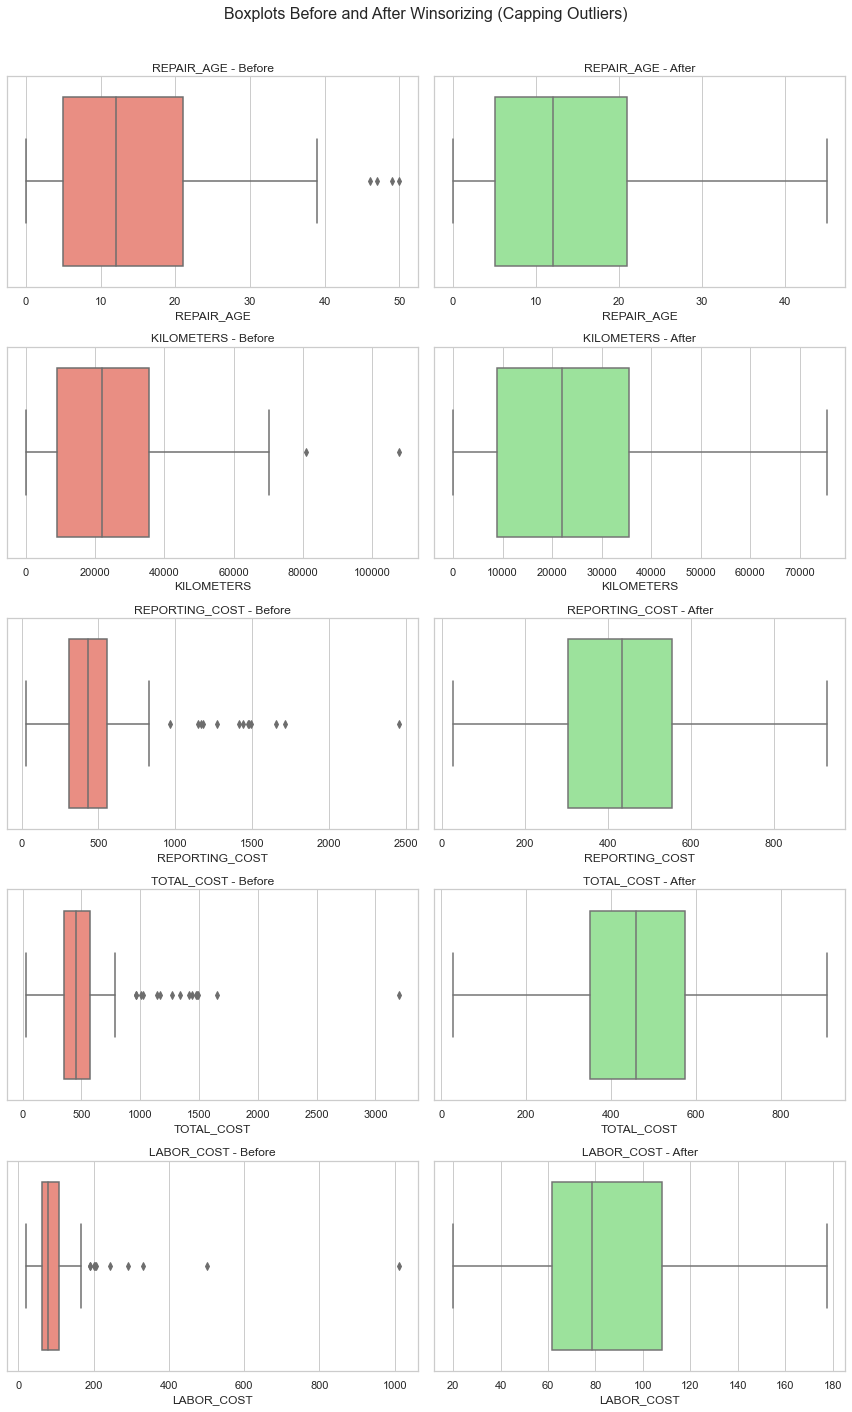

In [463]:
# Define numerical columns
numerical_columns = ['REPAIR_AGE', 'KILOMETERS', 'REPORTING_COST', 'TOTAL_COST', 'LABOR_COST']

# Function to apply IQR capping (Winsorizing) and update Data_copy directly
def cap_outliers_iqr(data_copy, columns):
    for col in columns:
        Q1 = data_copy[col].quantile(0.25)
        Q3 = data_copy[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        data_copy[col] = data_copy[col].clip(lower, upper)
    return data_copy

# Backup original data for comparison
Data = data_copy.copy()

# Apply Winsorizing directly to data_copy
data_copy = cap_outliers_iqr(data_copy, numerical_columns)

# Plot before and after boxplots
fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=2, figsize=(12, 4 * len(numerical_columns)))
fig.suptitle('Boxplots Before and After Winsorizing (Capping Outliers)', fontsize=16)

for i, col in enumerate(numerical_columns):
    sns.boxplot(data=Data, x=col, ax=axes[i, 0], color='salmon')
    axes[i, 0].set_title(f'{col} - Before')
    
    sns.boxplot(data=data_copy, x=col, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'{col} - After')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



## Top 5 Critical Columns that Might be Most Insightful for Stakeholders.

1. TOTAL COST
2. LABOR COST
3. REPAIR AGE
4. KILOMETERS
5. COMPLAINT_CODE

## Visualizations Using Python to Represent Insights For Stakeholders.

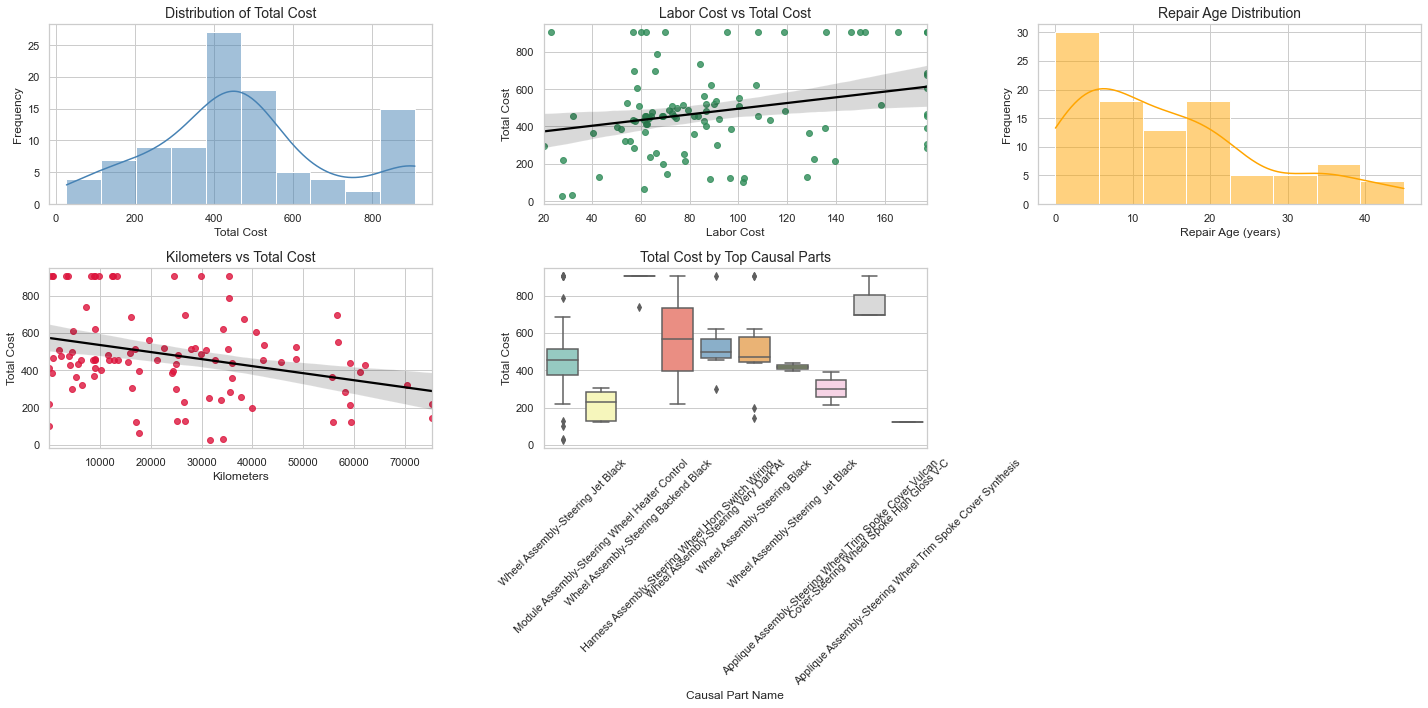

In [464]:
# Set seaborn style
sns.set(style="whitegrid")

# Create subplots (2x3 grid)
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

# Distribution of Total Cost
sns.histplot(data_copy["TOTAL_COST"], kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Distribution of Total Cost", fontsize=14)
axes[0, 0].set_xlabel("Total Cost")
axes[0, 0].set_ylabel("Frequency")

# Labor Cost vs Total Cost with regression line
sns.regplot(data=data_copy, x="LABOR_COST", y="TOTAL_COST", ax=axes[0, 1], color="seagreen", line_kws={"color": "black"})
axes[0, 1].set_title("Labor Cost vs Total Cost", fontsize=14)
axes[0, 1].set_xlabel("Labor Cost")
axes[0, 1].set_ylabel("Total Cost")

# Repair Age Distribution
sns.histplot(data_copy["REPAIR_AGE"], kde=True, ax=axes[0, 2], color="orange")
axes[0, 2].set_title("Repair Age Distribution", fontsize=14)
axes[0, 2].set_xlabel("Repair Age (years)")
axes[0, 2].set_ylabel("Frequency")

# Kilometers vs Total Cost with regression line
sns.regplot(data=data_copy, x="KILOMETERS", y="TOTAL_COST", ax=axes[1, 0], color="crimson", line_kws={"color": "black"})
axes[1, 0].set_title("Kilometers vs Total Cost", fontsize=14)
axes[1, 0].set_xlabel("Kilometers")
axes[1, 0].set_ylabel("Total Cost")

# Total Cost by Top Causal Parts
top_parts = data_copy['CAUSAL_PART_NAME'].value_counts().head(10).index
filtered_data = data_copy[data_copy['CAUSAL_PART_NAME'].isin(top_parts)]
sns.boxplot(data=filtered_data, x='CAUSAL_PART_NAME', y='TOTAL_COST', ax=axes[1, 1], palette="Set3")
axes[1, 1].set_title("Total Cost by Top Causal Parts", fontsize=14)
axes[1, 1].set_xlabel("Causal Part Name")
axes[1, 1].set_ylabel("Total Cost")
axes[1, 1].tick_params(axis='x', rotation=45)

# Empty slot
axes[1, 2].axis("off")

# Adjust layout
plt.tight_layout()
plt.show()



Sample Common Tags:
 ['assembly steering', 'assembly steering black', 'assembly steering dark', 'assembly steering jet', 'assembly steering wheel', 'black steering', 'black steering wheel', 'coming apart', 'cover replacement', 'heated steering', 'heated steering wheel', 'horn switch', 'horn switch wiring', 'jet black', 'jet black steering', 'removed replaced', 'replace steering', 'replace steering wheel', 'replaced steering', 'replaced steering wheel']


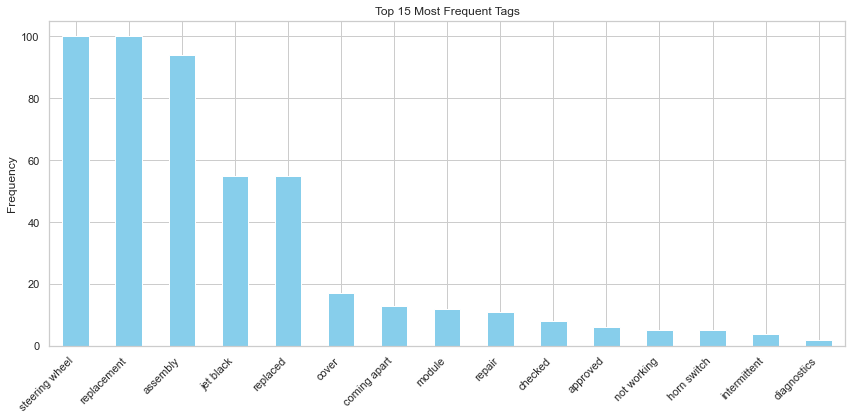

In [465]:
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict

# Combine relevant text columns
text_data = data_copy[['CORRECTION_VERBATIM', 'CUSTOMER_VERBATIM', 'CAUSAL_PART_NAME', 'GLOBAL_LABOR_CODE_DESCRIPTION']].fillna('').agg(' '.join, axis=1)

# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()    # remove extra spaces
    text = text.replace('assemblysteering', 'assembly steering')  # fix compound word
    return text

cleaned_text = text_data.apply(clean_text)

# Extract 2-3 word phrases for general tag discovery
vectorizer = CountVectorizer(ngram_range=(2, 3), max_features=50, stop_words='english')
X = vectorizer.fit_transform(cleaned_text)

# For older versions of sklearn
common_tags = vectorizer.get_feature_names()

print("Sample Common Tags:\n", common_tags[:20])

# Define keyword categories
components = ['steering wheel', 'heater module', 'horn switch', 'cover', 'bar', 'module', 'assembly', 'jet black']
symptoms = ['inoperative', 'not working', 'coming apart', 'no longer displayed', 'service message', 'intermittent']
actions = ['replaced', 'checked', 'diagnostics', 'approved', 'replacement', 'repair']

# Function to extract and categorize tags for each record
def extract_tags(row):
    text = f"{row['CORRECTION_VERBATIM']} {row['CUSTOMER_VERBATIM']} {row['CAUSAL_PART_NAME']} {row['GLOBAL_LABOR_CODE_DESCRIPTION']}"
    text = clean_text(text)
    tag_info = defaultdict(list)
    for word in components:
        if word in text:
            tag_info['component'].append(word)
    for word in symptoms:
        if word in text:
            tag_info['symptom'].append(word)
    for word in actions:
        if word in text:
            tag_info['action'].append(word)
    return dict(tag_info)

# Apply to each record
data_copy['TAGS'] = data_copy.apply(extract_tags, axis=1)

# Flatten all tags for frequency count
all_tags = data_copy['TAGS'].apply(lambda x: [tag for cat in x.values() for tag in cat])
flat_tags = [tag for sublist in all_tags for tag in sublist]
tag_series = pd.Series(flat_tags)
tag_counts = tag_series.value_counts()

# Visualize tag frequencies
plt.figure(figsize=(12, 6))
tag_counts.head(15).plot(kind='bar', color='skyblue')
plt.title('Top 15 Most Frequent Tags')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




In [466]:
# Moving clean data to the "file Anchal_Tiwari_DA_Task_2_Cleaned_Data.xlsx"
data_copy.to_excel("Anchal_Tiwari_DA_Task_2_Cleaned_and_Tagged_Data_file.xlsx", index= False)